<a href="https://colab.research.google.com/github/pranotosh2/Coffee-Shop-Sales/blob/main/skeletal_variation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Skeletal Variation

[Project extensions are at the bottom of this file]

The comparison of skeletons across species lead to historical insights in evolutionary biology. In this project, you will explore the bones of the human body and make comparisons to a wide variety of mammals and birds.


In [19]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'adult-human-skeleton.csv', 'bird-neck-bones.csv', and 'mammal-neck-bones.csv'.

# from google.colab import files
# uploaded = files.upload()

### Loading the Data

The file `'adult-human-skeleton.csv'` contains information about every bone in the human body.
Load the csv data and take a look.

Activity Goals:
- Import pandas.
- Load the skeleton data.
- Display the dataframe.

In [20]:
import pandas as pd
df = pd.read_csv('/adult-human-skeleton.csv')
df #display the dataframe

,name,region,subregion,side,fused_from
0,frontal,head,cranium,center,2
1,left parietal,head,cranium,left,1
2,right parietal,head,cranium,right,1
3,left temporal,head,cranium,left,1
4,right temporal,head,cranium,right,1
...,...,...,...,...,...
201,right distal pedal phalanx 1,foot,toes,right,1
202,right distal pedal phalanx 2,foot,toes,right,1
203,right distal pedal phalanx 3,foot,toes,right,1
204,right distal pedal phalanx 4,foot,toes,right,1


In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Each row represents one bone in the adult human body. We can see that adults have 206 bones. What can we learn about these bones?

### Claim: Half the bones are in the hands and feet

You might have heard the claim that over half the bones in your body are found in your hands and feet. Is this claim true or is it an urban legend?

Let's see how many bones are in each region using the `value_counts()` method.

Activity Goal:
- Find the counts for each value in the 'region' column.

In [22]:
df['region'].value_counts()

,count
region,
hand,54
foot,52
torso,50
head,28
neck,8
leg,8
arm,6


The hands have a total of 54 bones ,and the feet have 52 bones.

Earlier we saw that the entire body has 206 bones. Using python, we can calculate what proportion are in the hands and feet. Run the code below:

In [23]:
(54 + 52) / 206

0.5145631067961165

Over 51% of bones are found in the hands and feet. The claim is true!

### Baby bones

Infants have more bones than adults, but as the baby develops, groups of bones fuse together. This is detailed in the `'fused_from'` column of our data.

Let's sort the values in this `'fused_from'` column.

Activity Goals:
- Sort the dataframe by the `'fused_from'` column.
- Use descending order.

# New Section

In [24]:
df.sort_values(by='fused_from', ascending=False)

,name,region,subregion,side,fused_from
40,sternum,torso,chest,center,6
30,c2,neck,vertebra,center,5
82,sacrum,torso,pelvis,center,5
5,occipital,head,cranium,center,4
83,coccyx,torso,pelvis,center,4
...,...,...,...,...,...
201,right distal pedal phalanx 1,foot,toes,right,1
202,right distal pedal phalanx 2,foot,toes,right,1
203,right distal pedal phalanx 3,foot,toes,right,1
204,right distal pedal phalanx 4,foot,toes,right,1


This shows a wide variety of bone fusion across the body. For example, the sternum is formed from the fusion of 6 bones.

Before all this fusion takes place, how many bones do infants have? We can answer this by calculating the `sum()` of all the fused_from values.

Activity Goals:
- Select the `'fused_from'` column.
- Add up all values in that column.

In [25]:
df['fused_from'].sum()

np.int64(305)

Human infants have 305 bones, many of which fuse together, resulting in 206 bones in the adult body.

### Human neck bones

Necks are quite flexible. How many bones are in the human neck to allow for that flexibility?

Let's use the `query()` method to find out.

Activity Goal:
- Find all rows where the region is 'neck'.

In [26]:
df.query('region == "neck"')

,name,region,subregion,side,fused_from
28,hyoid,neck,throat,center,3
29,c1,neck,vertebra,center,3
30,c2,neck,vertebra,center,5
31,c3,neck,vertebra,center,3
32,c4,neck,vertebra,center,3
33,c5,neck,vertebra,center,3
34,c6,neck,vertebra,center,3
35,c7,neck,vertebra,center,3


The neck has 1 throat bone, and a stack of 7 neck vertebrae, named C1 through C7. The "C" stands for cervical, meaning neck. These 7 cervical vertebrae form the top of the spinal column.

So, humans have 7 neck vertebrae. What about other mammals?

### Mammal neck bones

This project includes the <code>'mammal-neck-bones.csv'</code> file. Let's load it so we can explore the necks of other mammals.

Activity Goals:
- Load the mammal neck data.
- Display it.

In [27]:
mammals = pd.read_csv('mammal-neck-bones.csv')
mammals #display the dataframe

,species,neck_vertebrae
0,cheetah,7
1,impala,7
2,giant panda,7
3,hartebeest,7
4,moose,7
...,...,...
297,alpaca,7
298,common wombat,7
299,red fox,7
300,fennec fox,7


The rows shown above all have 7 neck vertebrae, but is this true for all 302 mammals in this dataset? Let's use a `query()` to find the data for giraffes, which we know have really long necks.

Activity Goal:
- Show rows where the species is 'giraffe'.

In [28]:
mammals.query('species == "giraffe"')

,species,neck_vertebrae
108,giraffe,7


Despite their very long necks, giraffes also have 7 neck vertebrae!

So, do all mammals have 7 vertebrae? We can use another `query()` to search for any rows where neck_vertebrae is not 7.

Activity Goal:
- Search for rows where the number of vertebrae does not equal 7.

In [29]:
mammals.query('neck_vertebrae != 7')

,species,neck_vertebrae
27,pale-throated sloth,9
28,brown-throated sloth,9
60,hoffmann's two-toed sloth,6
291,west indian manatee,6


Aha! It looks like the only mammals without 7 vertebrae are manatees and sloths.

### Bird neck bones

While mammals mostly have 7 neck vertebrae, what about birds? Let's load in `'bird-neck-bones.csv'` to explore.

Activity Goals:
- Load the bird neck data.
- Display it.

In [30]:
birds = pd.read_csv('bird-neck-bones.csv')
birds #display the dataframe

,species,neck_vertebrae
0,cinereous vulture,13
1,guineafowl,14
2,red-legged partridge,14
3,blue-cheeked parrot,12
4,northern pintail,15
...,...,...
76,barn owl,12
77,eurasian hoopoe,13
78,murre,13
79,new zealand rockwren,13


Birds seem to have many more vertebrae than mammals. Let's make a bar plot of the value counts to get a sense of the distribution.

We will use the method `sort_index()` to sort the value counts by the number of neck vertebrae.

Activity Goals:
- Get the value counts for bird neck vertebrae.
- Sort by the index.
- Use pandas to make a bar plot.

<Axes: xlabel='neck_vertebrae'>

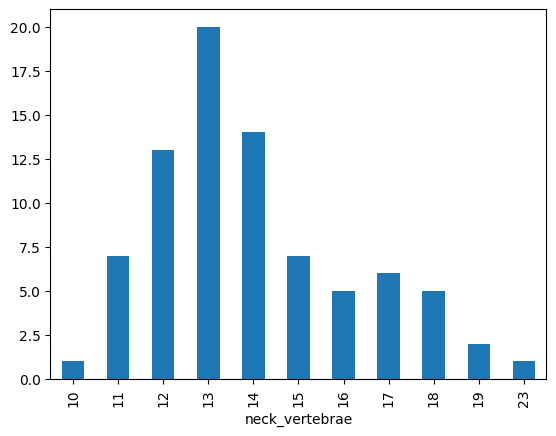

In [31]:
bird_counts = birds['neck_vertebrae'].value_counts()
bird_counts = bird_counts.sort_index()
bird_counts.plot.bar()


Birds have more diverse neck skeletons.

The most common number of neck vertebrae is 13, but it looks like 23 is the maximum.

Which bird has the maximum number of neck bones?

Activity Goal:
- Find the rows with the maximum number of neck vertebrae.

In [32]:
birds.query('neck_vertebrae == neck_vertebrae.max()')

,species,neck_vertebrae
28,mute swan,23


The beautiful Mute Swan takes the prize!

## Project extensions

Below are a few ideas for extensions.

1. Which bird has the fewest neck vertebra?

	- Find the row with the minimum number of neck vertebrae.

2. Do humans have more bones in the arms or legs?

	- Filter the rows where the region is `arm`.
	- Repeat with `leg`.

3. How many ribs to humans have?

	- Filter the rows where the name contains the word `rib`.

		- Hint: `name.str.contains("rib")`.

	- To count the number of rows, use the dataframe function `df.shape`.

	- This will return the number of rows and columns in the dataframe.

In [34]:
birds.query('neck_vertebrae == neck_vertebrae.min()')


,species,neck_vertebrae
11,blue-and-yellow macaw,10


In [40]:
df.query('region == "arm"')

,name,region,subregion,side,fused_from
86,left humerus,arm,upper-arm,left,3
87,right humerus,arm,upper-arm,right,3
88,left radius,arm,lower-arm,left,2
89,right radius,arm,lower-arm,right,2
90,left ulna,arm,lower-arm,left,2
91,right ulna,arm,lower-arm,right,2


In [41]:
df.query('region == "leg"')

,name,region,subregion,side,fused_from
146,left femur,leg,upper-leg,left,3
147,right femur,leg,upper-leg,right,3
148,left patella,leg,knee,left,1
149,right patella,leg,knee,right,1
150,left tibia,leg,lower-leg,left,2
151,right tibia,leg,lower-leg,right,2
152,left fibula,leg,lower-leg,left,2
153,right fibula,leg,lower-leg,right,2


In [45]:
df.query('name.str.contains("rib")')

,name,region,subregion,side,fused_from
41,left rib 1,torso,chest,left,1
42,left rib 2,torso,chest,left,1
43,left rib 3,torso,chest,left,1
44,left rib 4,torso,chest,left,1
45,left rib 5,torso,chest,left,1
46,left rib 6,torso,chest,left,1
47,left rib 7,torso,chest,left,1
48,left rib 8,torso,chest,left,1
49,left rib 9,torso,chest,left,1
50,left rib 10,torso,chest,left,1


In [46]:
df.shape

(206, 5)

In [48]:
df.shape[0]

206

In [49]:
df.shape[1]

5